# Weather Trend Forecasting Assessment
PM Accelerator Data Scientist Assessment

In [2]:
import kagglehub
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

C:\Sarthak\Internship\PM Accelerator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'pandas'

In [52]:
path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
df = pd.read_csv(path + "/GlobalWeatherRepository.csv")
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [53]:
# Continue with cleaning, EDA, modeling, ensemble, feature importance and analyses from the assessment script

In [54]:
df.shape

(149100, 41)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149100 entries, 0 to 149099
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       149100 non-null  object 
 1   location_name                 149100 non-null  object 
 2   latitude                      149100 non-null  float64
 3   longitude                     149100 non-null  float64
 4   timezone                      149100 non-null  object 
 5   last_updated_epoch            149100 non-null  int64  
 6   last_updated                  149100 non-null  object 
 7   temperature_celsius           149100 non-null  float64
 8   temperature_fahrenheit        149100 non-null  float64
 9   condition_text                149100 non-null  object 
 10  wind_mph                      149100 non-null  float64
 11  wind_kph                      149100 non-null  float64
 12  wind_degree                   149100 non-nul

In [56]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [57]:
print("Duplicates :",df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates")
print(df.shape)

Duplicates : 0
Shape After Removing Duplicates
(149100, 41)


In [58]:
df.fillna(
    df.median(numeric_only=True),
    inplace=True
)

In [59]:
# Weather data contains legitimate extreme events, therefore domain-based thresholds
# were used instead of IQR so that meaningful climatic observations are retained.

df = df[(df["temperature_celsius"] >= -60) & (df["temperature_celsius"] <= 60)]

df = df[(df["humidity"] >= 0) & (df["humidity"] <= 100)]

df = df[(df["cloud"] >= 0) & (df["cloud"] <= 100)]

df = df[(df["uv_index"] >= 0) & (df["uv_index"] <= 15)]

df = df[(df["pressure_mb"] >= 870) & (df["pressure_mb"] <= 1085)]

df = df[(df["wind_mph"] >= 0) & (df["wind_mph"] <= 250)]

df = df[(df["visibility_miles"] >= 0) & (df["visibility_miles"] <= 30)]

print(df.shape)

(148941, 41)


In [60]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

df["year"] = df["last_updated"].dt.year
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,day
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,16
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,16
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,16
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,16
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,16


In [61]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,148941.0,19.265349,-41.3,4.0503,17.25,40.4,65.3,24.393031
longitude,148941.0,21.891844,-175.2,-6.8361,21.4333,49.8822,179.22,65.811983
last_updated_epoch,148941.0,1749043119.106895,1715849100.0,1732437000.0,1749027600.0,1765610100.0,1782195300.0,19163344.740976
last_updated,148941,2025-06-04 15:28:10.470723328,2024-05-16 01:45:00,2024-11-24 16:45:00,2025-06-04 22:00:00,2025-12-12 23:15:00,2026-06-23 19:15:00,NaN
temperature_celsius,148941.0,21.295424,-29.8,16.0,23.6,27.9,49.2,9.544591
temperature_fahrenheit,148941.0,70.333541,-21.6,60.8,74.5,82.2,120.6,17.180127
wind_mph,148941.0,7.940001,2.2,3.8,6.7,11.0,169.1,5.205509
wind_kph,148941.0,12.781974,3.6,6.1,10.8,17.6,272.2,8.372642
wind_degree,148941.0,169.324726,1.0,80.0,162.0,256.0,360.0,103.526832
pressure_mb,148941.0,1014.033396,947.0,1010.0,1014.0,1018.0,1080.0,6.907002


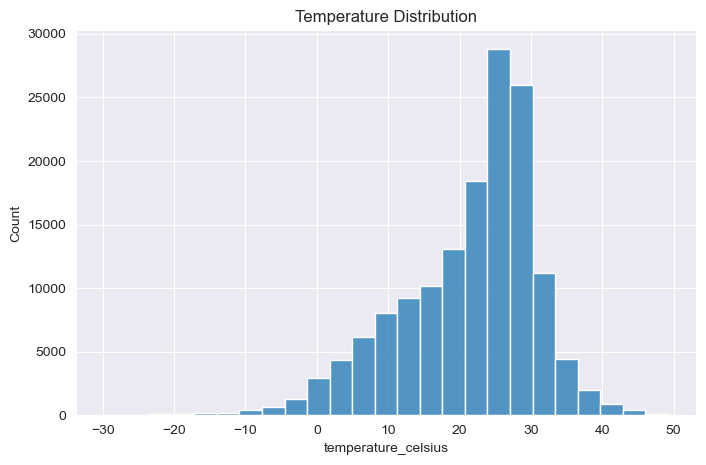

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(df["temperature_celsius"],bins=25)

plt.title("Temperature Distribution")

plt.show()

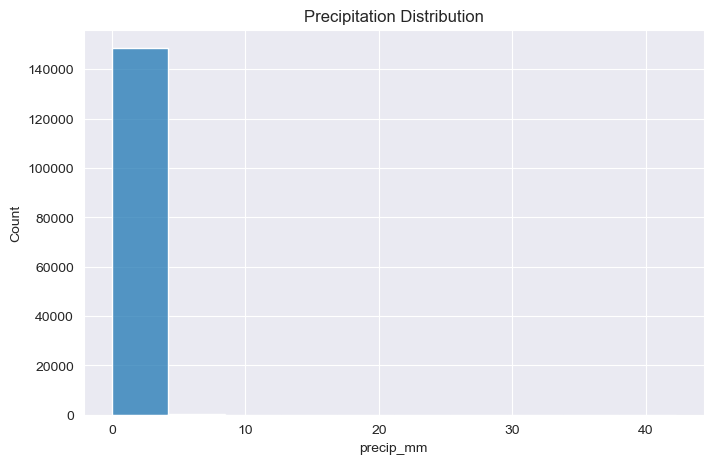

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(df["precip_mm"], bins=10)

plt.title(
    "Precipitation Distribution"
)

plt.show()

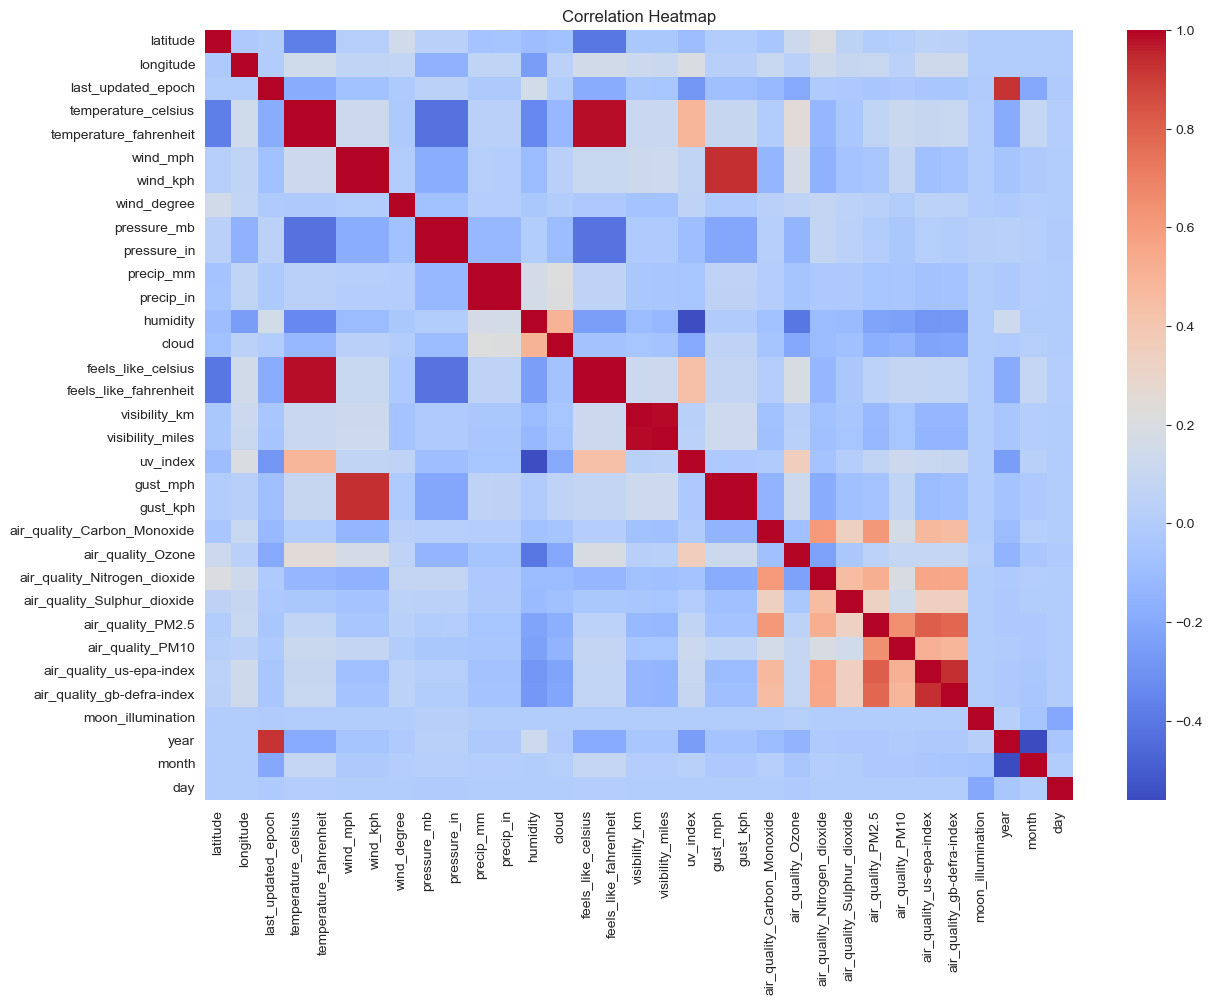

In [64]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

plt.figure(figsize=(14,10))

sns.heatmap(
    df[numeric_cols].corr(),
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

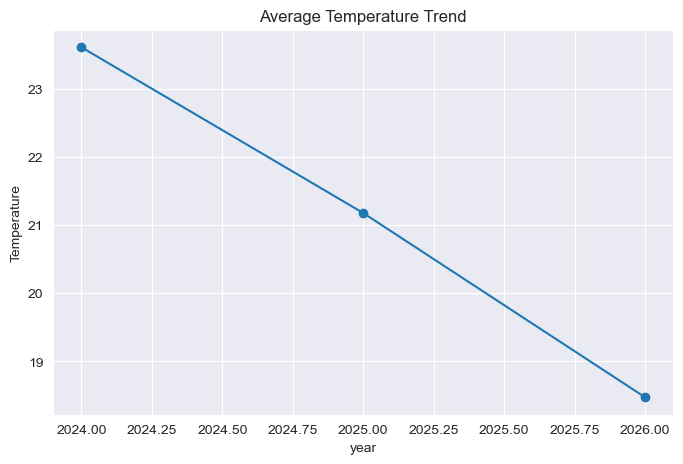

In [65]:
temp_trend = df.groupby(
    "year"
)["temperature_celsius"].mean()

plt.figure(figsize=(8,5))

temp_trend.plot(
    marker="o"
)

plt.title(
    "Average Temperature Trend"
)

plt.ylabel(
    "Temperature"
)

plt.show()

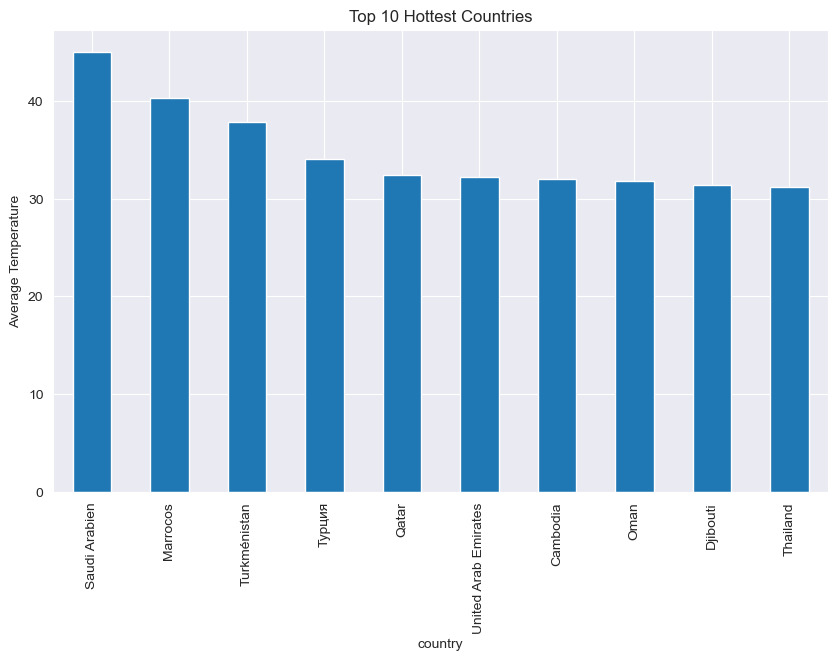

In [66]:
country_temp = df.groupby("country")["temperature_celsius"].mean()

country_temp = country_temp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

country_temp.plot(kind="bar")

plt.title("Top 10 Hottest Countries")

plt.ylabel("Average Temperature")

plt.show()

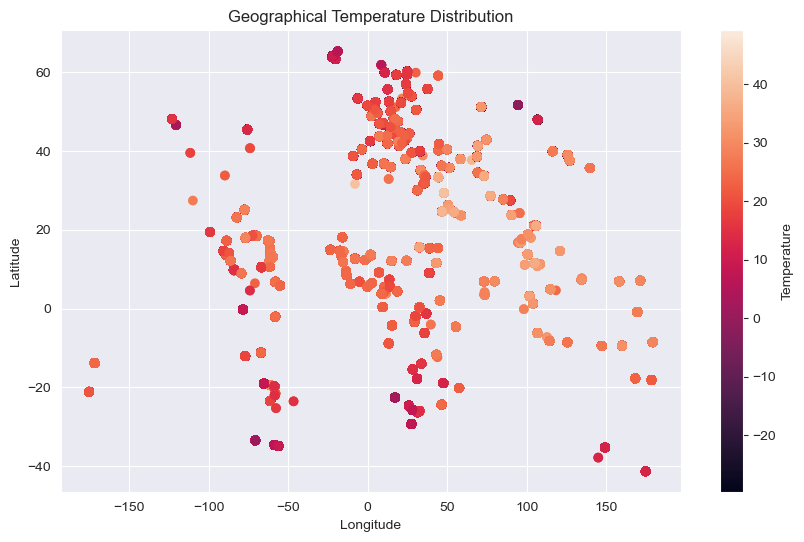

In [67]:
plt.figure(figsize=(10,6))

plt.scatter(df["longitude"], df["latitude"], c=df["temperature_celsius"])

plt.colorbar(label="Temperature")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Geographical Temperature Distribution")

plt.show()

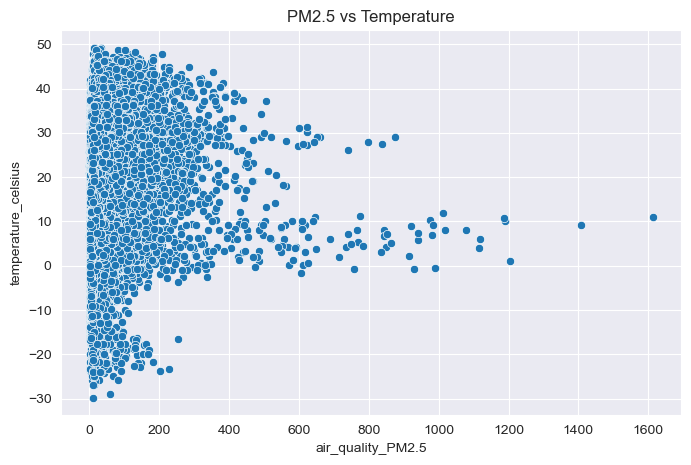

In [68]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="air_quality_PM2.5", y="temperature_celsius", data=df)

plt.title("PM2.5 vs Temperature")

plt.show()

In [69]:
cols_new= ['country', 'location_name', 'latitude', 'longitude', 'timezone','temperature_celsius','condition_text', 'wind_mph', 'wind_degree', 'wind_direction', 'pressure_mb','precip_in', 'humidity', 'cloud', 'feels_like_celsius','visibility_miles','uv_index', 'gust_mph','air_quality_Carbon_Monoxide','air_quality_Ozone', 'air_quality_Nitrogen_dioxide','air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10','air_quality_gb-defra-index', 'sunrise','sunset', 'moonrise', 'moonset','moon_phase', 'moon_illumination']

df_new= pd.DataFrame(df[cols_new])
df_new.head()

,country,location_name,latitude,longitude,timezone,temperature_celsius,condition_text,wind_mph,wind_degree,wind_direction,...,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,26.6,Partly Cloudy,8.3,338,NNW,...,0.2,8.4,26.6,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,19.0,Partly cloudy,6.9,320,NW,...,0.1,1.1,2.0,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,23.0,Sunny,9.4,280,W,...,13.4,10.4,18.4,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,6.3,Light drizzle,7.4,215,SW,...,0.2,0.7,0.9,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,26.0,Partly cloudy,8.1,150,SSE,...,31.5,183.4,262.3,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [70]:
drop_cols = ["temperature_fahrenheit", "feels_like_celsius", "feels_like_fahrenheit", "last_updated", "last_updated_epoch", "sunrise", "sunset", "moonrise", "moonset"]

for col in drop_cols:
    if col in df_new.columns:
        df_new.drop(col,axis=1,inplace=True)

In [71]:
categorical_cols = df_new.select_dtypes(include="object").columns
df_new = pd.get_dummies(df_new,columns=categorical_cols, drop_first=True)

In [72]:
X = df_new.drop("temperature_celsius",axis=1)
y = df_new["temperature_celsius"]
print(X.shape)

(148941, 774)


In [73]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [74]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [75]:
ridge= Ridge()
ridge.fit(X_train,y_train)
ridge_pred= ridge.predict(X_test)

In [76]:
print(X_train.shape)

(119152, 774)


In [77]:
rf = RandomForestRegressor(n_estimators=25, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [78]:
ensemble = VotingRegressor([("lr",ridge),("rf",rf)])
ensemble.fit(X_train,y_train)
ens_pred = ensemble.predict(X_test)

In [79]:
def evaluate(y_true,y_pred,name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print("\n",name)
    print("MAE :",mae)
    print("MSE :",mse)
    print("RMSE :",rmse)
    print("R2 :",r2)

In [81]:
evaluate(y_test, ridge_pred, "Ridge Regression")

evaluate(y_test, rf_pred, "Random Forest")

evaluate(y_test, ens_pred, "Ensemble Model")


 Ridge Regression
MAE : 3.21129330493955
MSE : 18.734134745834186
RMSE : 4.328294669478291
R2 : 0.7938074870067888

 Random Forest
MAE : 2.7959790756693113
MSE : 14.948394193050742
RMSE : 3.8663153250932267
R2 : 0.8354742823356899

 Ensemble Model
MAE : 2.6671295138237125
MSE : 13.399760613903396
RMSE : 3.6605683457495224
R2 : 0.8525189259086239
